Aprendizaje Automatico 1

Trabajo Práctico Nº 2

Integrantes: Quinteros, Lasarte, Lazarte

Columnas:


*   Date (Temporal): Fecha del registro (formato año-mes-día).
*   Location (Catagórica): Ciudad meteorológica donde se tomó la medición.
*   MinTemp (Numérica): Temperatura mínima del día (°C).
*   MaxTemp (Numérica): Temperatura máxima del día (°C).
*   Rainfall (Numérica): Cantidad de lluvia caída en el día (mm).
*   Evaporatio (Numérica): Cantidad de agua evaporada (mm).
*   Sunshine (Numérica): Horas de sol durante el día.
*   WindGustDir (Catagórica): Dirección de la ráfaga de viento más fuerte.
*   WindGustSpeed (Numérica): Velocidad máxima de ráfaga de viento (km/h).
*   WindDir9am (Catagórica): Dirección del viento a las 9 am.
*   WindDir3pm (Catagórica): Dirección del viento a las 3 pm.
*   WindSpeed9am (Numérica): Velocidad del viento a las 9 am.
*   WindSpeed3pm (Numérica): Velocidad del viento a las 3 pm.
*   Humidity9am (Numérica): Humedad relativa (%) a las 9 am.
*   Humidity3pm (Numérica): Humedad relativa (%) a las 3 pm.
*   Pressure9am (Numérica): Presión atmosférica (hPa) a las 9 am.
*   Pressure3pm (Numérica): Presión atmosférica (hPa) a las 3 pm.
*   Cloud9am (Numérica): Nubosidad a las 9 am (escala de 0 a 8, donde 8 es cielo totalmente cubierto).
*   Cloud3pm (Numérica): Nubosidad a las 3 pm.
*   Temp9am (Numérica): Temperatura medida a las 9 am.
*   Temp3pm (Numérica): Temperatura medida a las 3 pm.
*   RainToday (Catagórica): Indica si llovió ese día (Yes/No).
*   RainTomorrow (Catagórica): Indica si va a llover al día siguiente.
*   RainfallTomorrow (Numérica): Cantidad de lluvia del día siguiente (mm).



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
clima = pd.read_csv('weatherAUS_2026C1.csv')

In [ ]:
clima.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [ ]:
clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

In [ ]:
clima = clima.drop('Unnamed: 0', axis = 1) # Se borra porque es simplemente un índice (contador de filas). No aporta información meteorológica.

In [ ]:
clima.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [ ]:
clima.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainfallTomorrow
count,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142153.000000
mean,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,2.361242
std,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,8.479084
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,371.000000


In [ ]:
clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              145412 non-null  object 
 1   Location          145412 non-null  object 
 2   MinTemp           143928 non-null  float64
 3   MaxTemp           144159 non-null  float64
 4   Rainfall          142152 non-null  float64
 5   Evaporation       82658 non-null   float64
 6   Sunshine          75616 non-null   float64
 7   WindGustDir       135096 non-null  object 
 8   WindGustSpeed     135159 non-null  float64
 9   WindDir9am        134850 non-null  object 
 10  WindDir3pm        141186 non-null  object 
 11  WindSpeed9am      143645 non-null  float64
 12  WindSpeed3pm      142351 non-null  float64
 13  Humidity9am       142759 non-null  float64
 14  Humidity3pm       140907 non-null  float64
 15  Pressure9am       130351 non-null  float64
 16  Pressure3pm       13

In [ ]:
print("Cantidad de valores NaN:")
print(f"\n{clima.isnull().sum()}")

Cantidad de valores NaN:

Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64


In [ ]:
(clima['Cloud3pm'].isnull().sum() / clima.shape[0]) * 100

np.float64(40.80543558991005)

Tratamiento de NaNs:



*   Rainfall: Remplazar NaN por 0
*   WindGustDir, WindDir9am, WindDir3pm, RainToday: Remplazar usando moda por Location
*   MinTemp, MaxTemp, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Temp9am, Temp3pm: Remplazar usando media o mediana agrupada por Location
*   Cloud9am, Cloud3pm: Se puede remplazar usando mediana por Location sufriendo bastante ruido por la cantidad de datos faltantes o eliminarlos directamente
*   Evaporation, Sunshine: Imputar con la media podria generar mucho ruido para el modelo ya que tiene muchos valores faltantes, asi que es mejor eliminarlas
*   RainToday: Los valores nulos se remplazan por su moda "No"
*   RainTomorrow: Se eliminan las filas con valores nulos ya que no se puede entrenar el modelo con datos que no se sabe la respuesta correcta
*   RainfallTomorrow: Se elimina la columna ya que no se usa en el modelo por problemas de Data Leakage
*   Agregar variables indicadoras como 'Humidity9am_missing'




Como no sabemos cuales son las variables mas importantes para el modelo creamos mas datasets con pequeñas variantes.

In [ ]:
clima1 = clima.copy()
clima1 = clima1.drop(columns=['RainfallTomorrow'], errors='ignore')
clima1 = clima1.dropna(subset=['RainTomorrow'])

clima1['Rainfall'] = clima1['Rainfall'].fillna(0)
clima1['RainToday'] = clima1['RainToday'].fillna('No')

for c in ['WindGustDir','WindDir9am','WindDir3pm','RainToday']:
    global_mode = clima1[c].mode(dropna=True)
    global_mode = global_mode.iloc[0] if len(global_mode)>0 else np.nan
    clima1[c] = clima1.groupby('Location')[c].transform(lambda x: x.fillna(x.mode().iloc[0] if len(x.mode())>0 else global_mode))

for c in ['Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Temp9am','Temp3pm','Cloud9am','Cloud3pm','Evaporation','Sunshine']:
    if c in clima1.columns:
        clima1[c+'_missing'] = clima1[c].isna().astype(int)

for c in ['MinTemp','MaxTemp','WindGustSpeed','WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Temp9am','Temp3pm']:
    if c in clima1.columns:
        clima1[c] = clima1.groupby('Location')[c].transform(lambda x: x.fillna(x.median() if not np.isnan(x.median()) else clima1[c].median()))

for c in ['Cloud9am','Cloud3pm','Evaporation','Sunshine']:
    if c in clima1.columns:
        clima1[c] = clima1.groupby('Location')[c].transform(lambda x: x.fillna(x.median() if not np.isnan(x.median()) else clima1[c].median()))

clima1['RainToday'] = clima1['RainToday'].map({'Yes':1,'No':0}).astype(int)

clima2 = clima.copy()
clima2 = clima2.drop(columns=['RainfallTomorrow'], errors='ignore')
clima2 = clima2.dropna(subset=['RainTomorrow'])

clima2['Rainfall'] = clima2['Rainfall'].fillna(0)
clima2['RainToday'] = clima2['RainToday'].fillna('No')

for c in ['WindGustDir','WindDir9am','WindDir3pm','RainToday']:
    global_mode = clima2[c].mode(dropna=True)
    global_mode = global_mode.iloc[0] if len(global_mode)>0 else np.nan
    clima2[c] = clima2.groupby('Location')[c].transform(lambda x: x.fillna(x.mode().iloc[0] if len(x.mode())>0 else global_mode))

clima2 = clima2.drop(columns=[c for c in ['Evaporation','Sunshine'] if c in clima2.columns])

for c in ['Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Temp9am','Temp3pm','Cloud9am','Cloud3pm']:
    if c in clima2.columns:
        clima2[c+'_missing'] = clima2[c].isna().astype(int)

for c in ['MinTemp','MaxTemp','WindGustSpeed','WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Temp9am','Temp3pm']:
    if c in clima2.columns:
        clima2[c] = clima2.groupby('Location')[c].transform(lambda x: x.fillna(x.median() if not np.isnan(x.median()) else clima2[c].median()))

for c in ['Cloud9am','Cloud3pm']:
    if c in clima2.columns:
        clima2[c] = clima2.groupby('Location')[c].transform(lambda x: x.fillna(x.median() if not np.isnan(x.median()) else clima2[c].median()))

clima2['RainToday'] = clima2['RainToday'].map({'Yes':1,'No':0}).astype(int)

clima1 = pd.get_dummies(clima1, columns=['WindGustDir','WindDir9am','WindDir3pm'])
clima2 = pd.get_dummies(clima2, columns=['WindGustDir','WindDir9am','WindDir3pm'])

clima1.to_csv('dataset_imputado.csv', index=False)
clima2.to_csv('dataset_sin_evap_sun.csv', index=False)

In [ ]:
print("Cantidad de valores NaN:")
print(f"\n{clima1.isnull().sum()}")

Cantidad de valores NaN:

Date              0
Location          0
MinTemp           0
MaxTemp           0
Rainfall          0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 78, dtype: int64


In [ ]:
clima1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142153 entries, 0 to 145411
Data columns (total 78 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 142153 non-null  object 
 1   Location             142153 non-null  object 
 2   MinTemp              142153 non-null  float64
 3   MaxTemp              142153 non-null  float64
 4   Rainfall             142153 non-null  float64
 5   Evaporation          142153 non-null  float64
 6   Sunshine             142153 non-null  float64
 7   WindGustSpeed        142153 non-null  float64
 8   WindSpeed9am         142153 non-null  float64
 9   WindSpeed3pm         142153 non-null  float64
 10  Humidity9am          142153 non-null  float64
 11  Humidity3pm          142153 non-null  float64
 12  Pressure9am          142153 non-null  float64
 13  Pressure3pm          142153 non-null  float64
 14  Cloud9am             142153 non-null  float64
 15  Cloud3pm             1

In [ ]:
clima1.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Humidity9am_missing,Humidity3pm_missing,Pressure9am_missing,Pressure3pm_missing,Temp9am_missing,Temp3pm_missing,Cloud9am_missing,Cloud3pm_missing,Evaporation_missing,Sunshine_missing
count,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,...,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000
mean,12.191872,23.228622,2.327214,5.132753,8.049748,39.891905,13.999887,18.566355,68.915082,51.544884,...,0.012480,0.025388,0.098556,0.098324,0.006359,0.019169,0.377347,0.401511,0.427793,0.476845
std,6.414795,7.129311,8.427504,3.224992,2.799400,13.189957,8.889274,8.819516,19.020224,20.676460,...,0.111013,0.157301,0.298066,0.297753,0.079492,0.137121,0.484725,0.490206,0.494760,0.499465
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.600000,17.900000,0.000000,3.600000,7.700000,31.000000,7.000000,12.000000,57.000000,36.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,22.700000,0.000000,4.800000,8.500000,38.000000,13.000000,18.000000,70.000000,52.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.800000,28.200000,0.600000,5.600000,9.400000,47.000000,19.000000,24.000000,83.100000,65.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
print("Cantidad de valores NaN:")
print(f"\n{clima2.isnull().sum()}")

Cantidad de valores NaN:

Date              0
Location          0
MinTemp           0
MaxTemp           0
Rainfall          0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 74, dtype: int64


In [ ]:
clima2.describe()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,Temp3pm,RainToday,Humidity9am_missing,Humidity3pm_missing,Pressure9am_missing,Pressure3pm_missing,Temp9am_missing,Temp3pm_missing,Cloud9am_missing,Cloud3pm_missing
count,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,...,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000,142153.000000
mean,12.191872,23.228622,2.327214,39.891905,13.999887,18.566355,68.915082,51.544884,1017.642616,1015.250660,...,21.710851,0.221248,0.012480,0.025388,0.098556,0.098324,0.006359,0.019169,0.377347,0.401511
std,6.414795,7.129311,8.427504,13.189957,8.889274,8.819516,19.020224,20.676460,6.754432,6.689675,...,6.959531,0.415088,0.111013,0.157301,0.298066,0.297753,0.079492,0.137121,0.484725,0.490206
min,-9.700000,-5.100000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,...,-5.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.600000,17.900000,0.000000,31.000000,7.000000,12.000000,57.000000,36.900000,1013.500000,1011.000000,...,16.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,22.700000,0.000000,38.000000,13.000000,18.000000,70.000000,52.100000,1017.600000,1015.200000,...,21.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.800000,28.200000,0.600000,47.000000,19.000000,24.000000,83.100000,65.700000,1021.800000,1019.400000,...,26.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,34.100000,49.100000,371.000000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,...,47.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


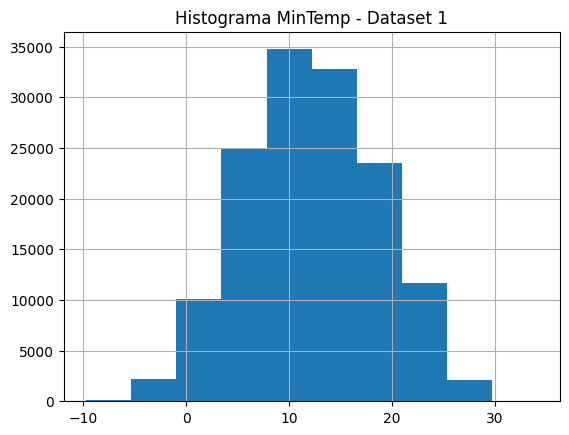

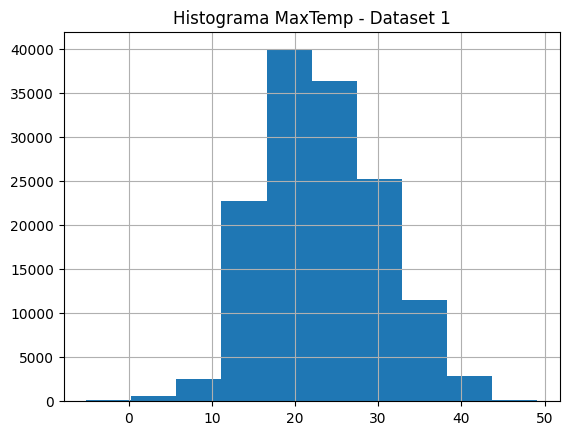

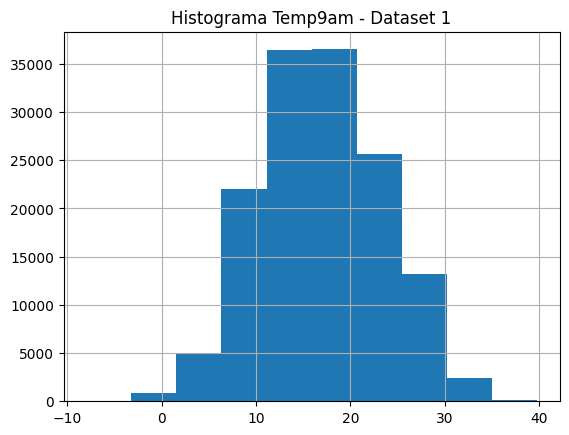

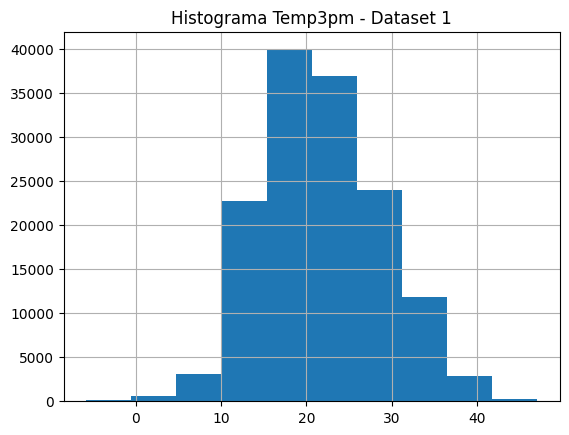

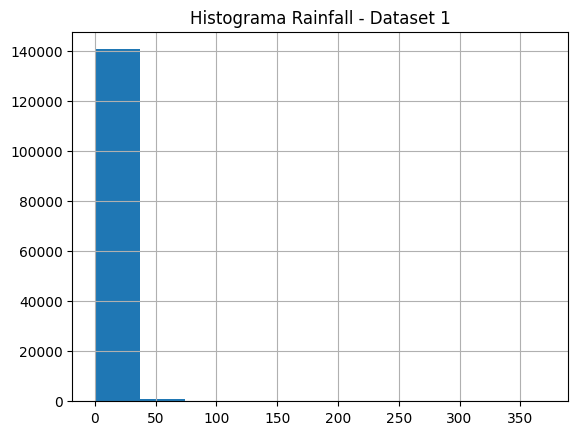

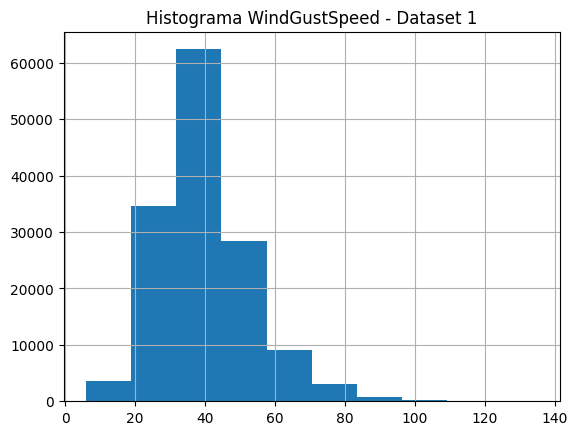

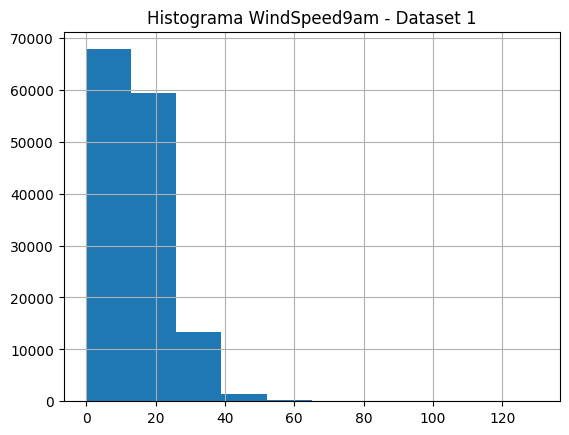

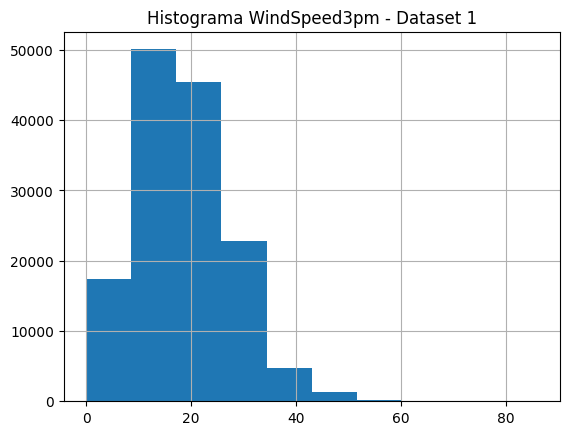

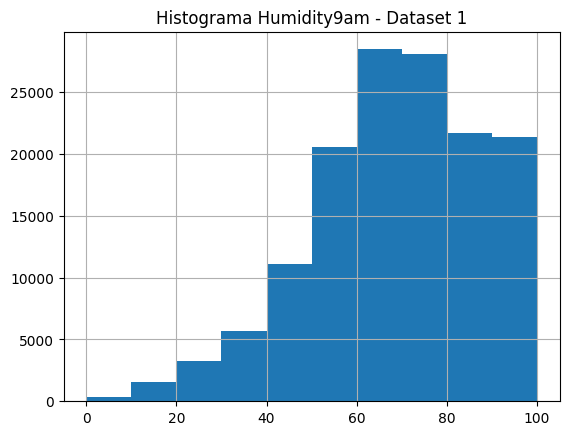

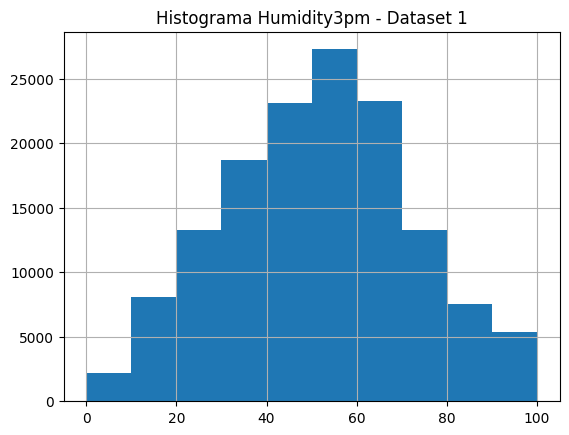

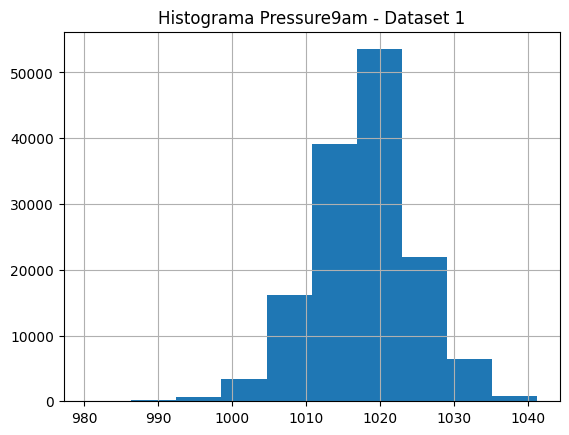

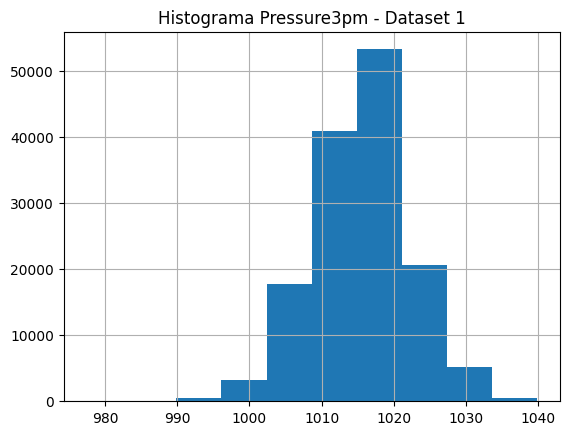

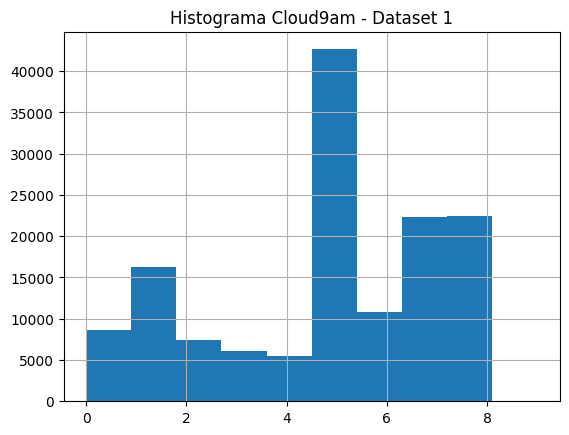

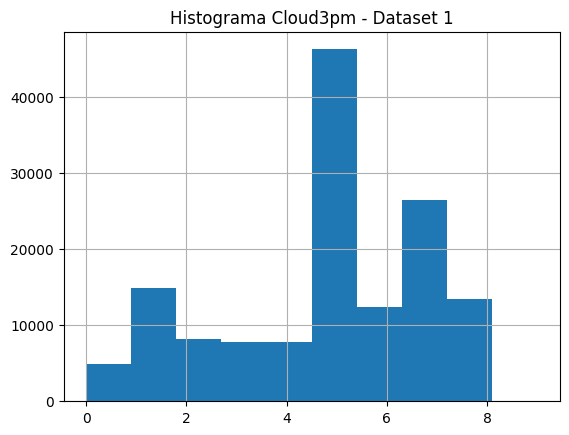

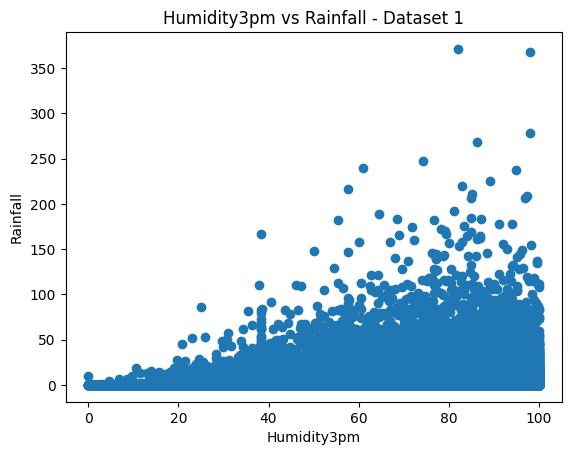

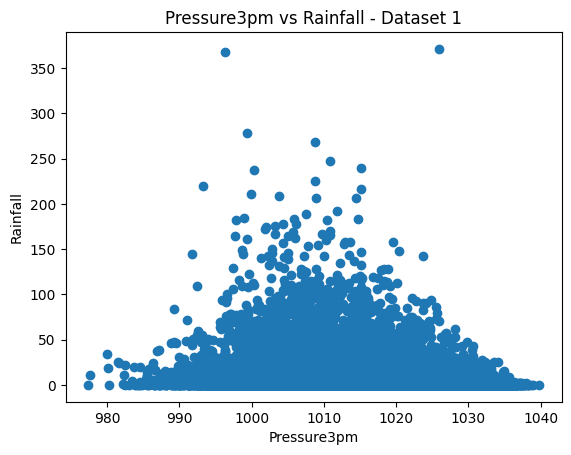

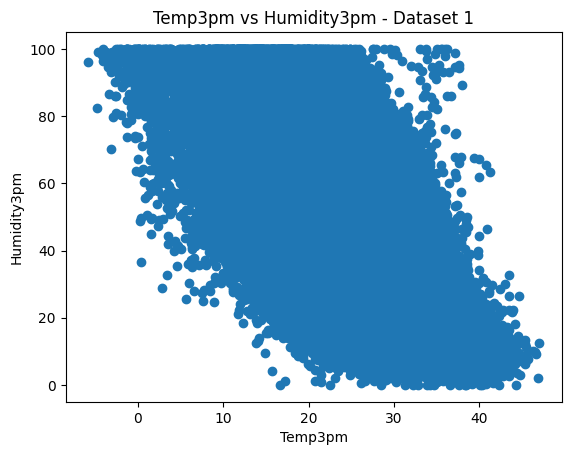

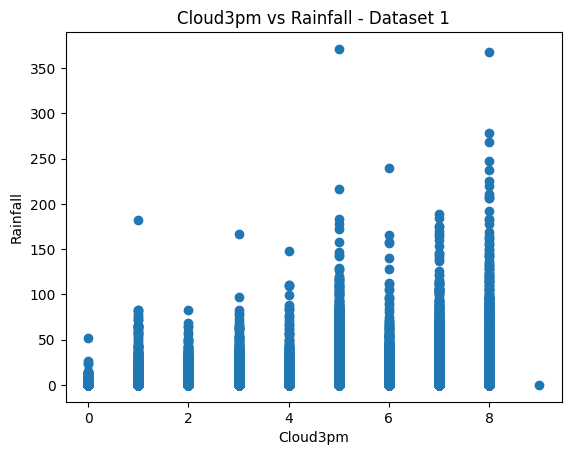

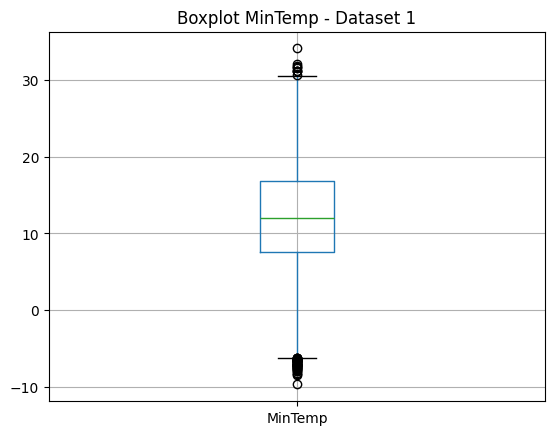

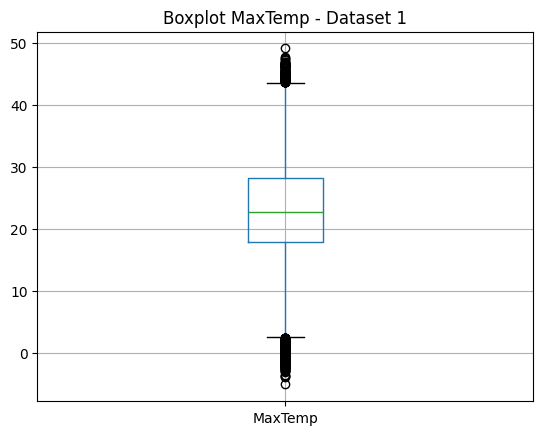

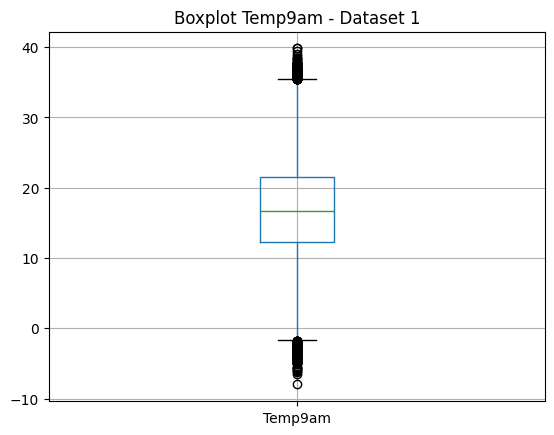

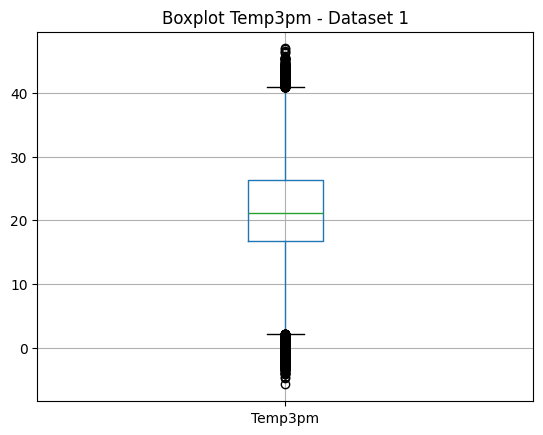

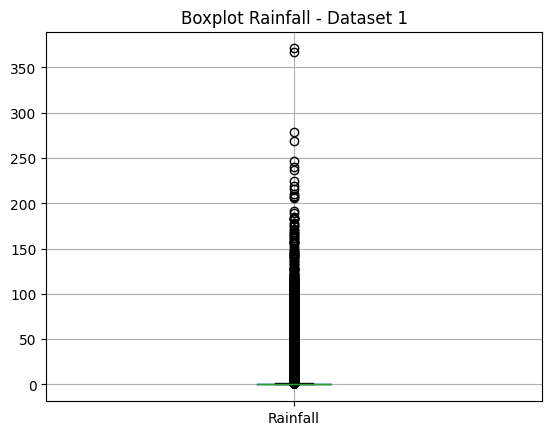

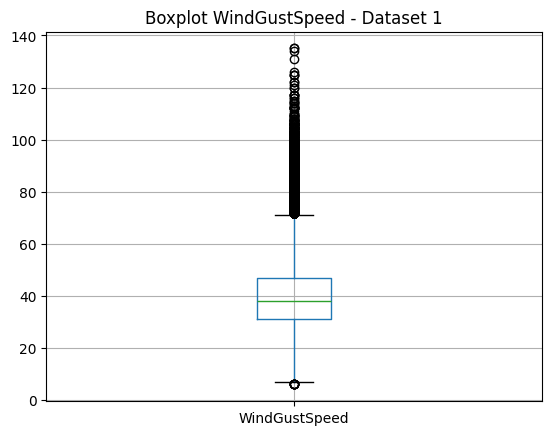

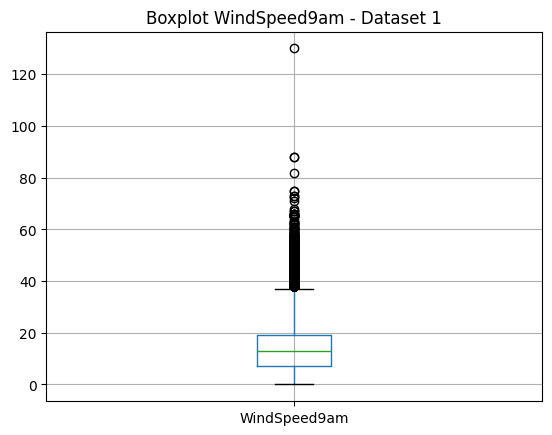

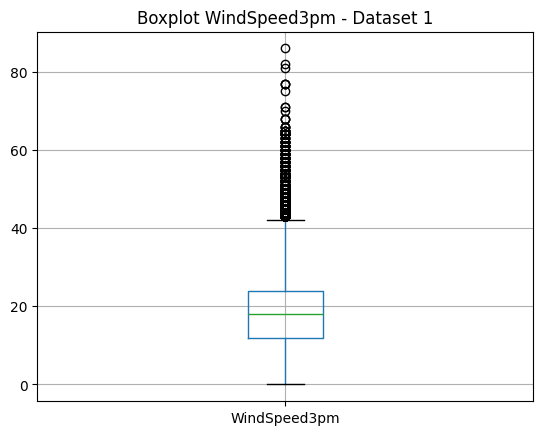

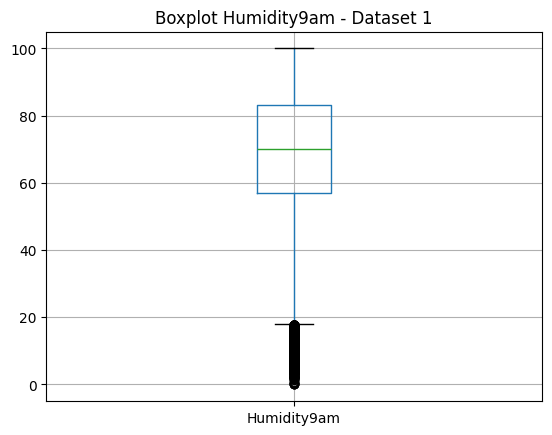

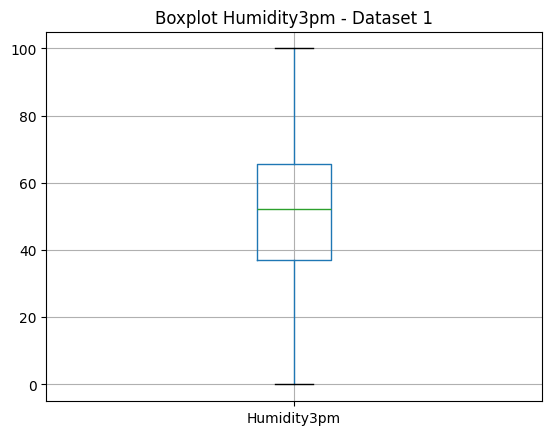

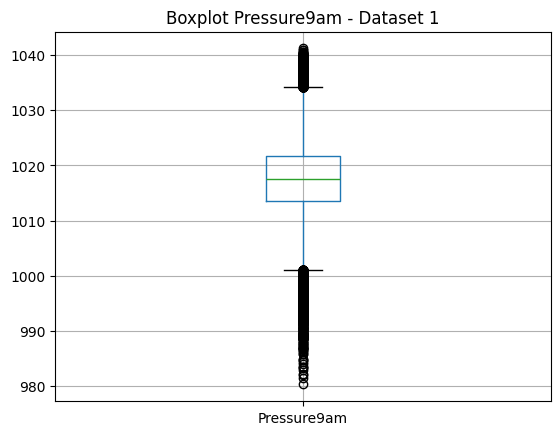

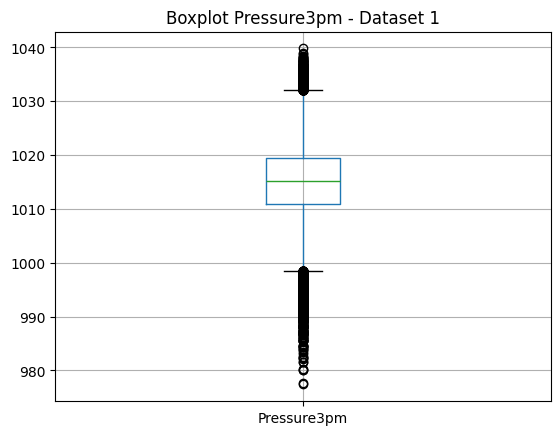

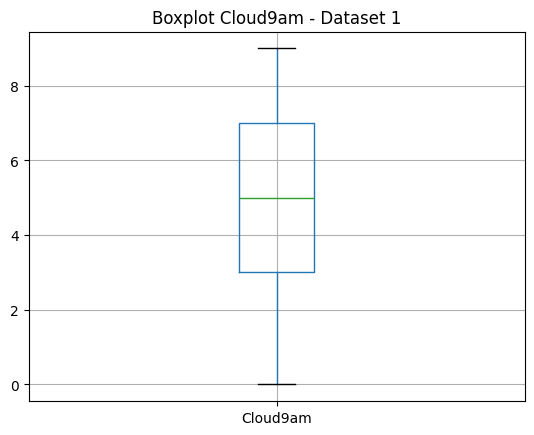

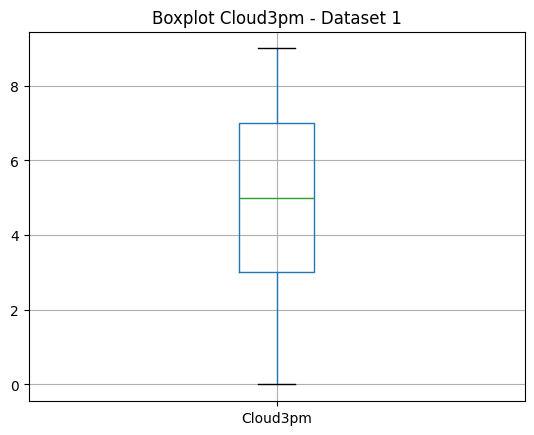

In [ ]:
df1 = pd.read_csv('dataset_imputado.csv')

numericas = [
    'MinTemp','MaxTemp','Temp9am','Temp3pm',
    'Rainfall','WindGustSpeed','WindSpeed9am','WindSpeed3pm',
    'Humidity9am','Humidity3pm','Pressure9am','Pressure3pm',
    'Cloud9am','Cloud3pm'
]

numericas = [c for c in numericas if c in df1.columns]

for c in numericas:
    plt.figure()
    df1[c].hist()
    plt.title(f'Histograma {c} - Dataset 1')
    plt.show()

pares = [
    ('Humidity3pm','Rainfall'),
    ('Pressure3pm','Rainfall'),
    ('Temp3pm','Humidity3pm'),
    ('Cloud3pm','Rainfall')
]

for x,y in pares:
    if x in df1.columns and y in df1.columns:
        plt.figure()
        plt.scatter(df1[x], df1[y])
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f'{x} vs {y} - Dataset 1')
        plt.show()

for c in numericas:
    plt.figure()
    df1.boxplot(column=c)
    plt.title(f'Boxplot {c} - Dataset 1')
    plt.show()

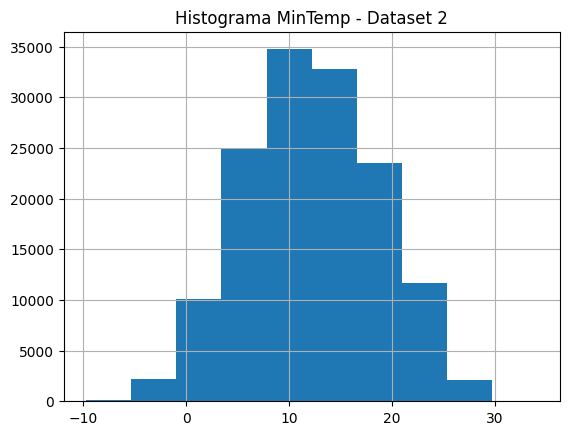

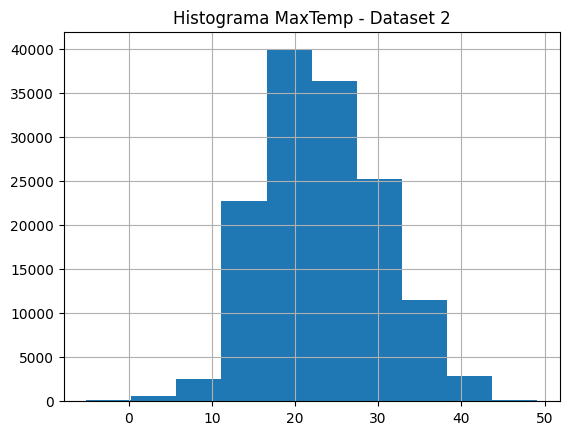

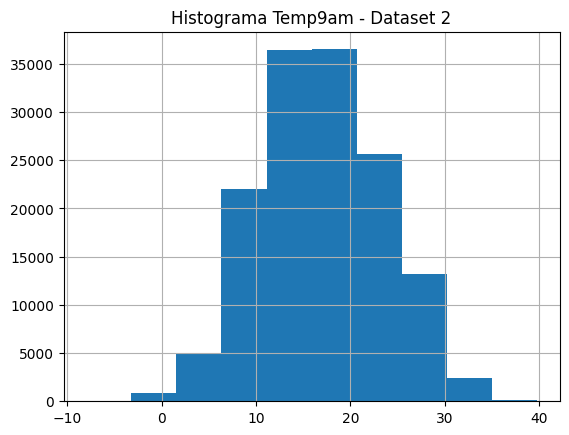

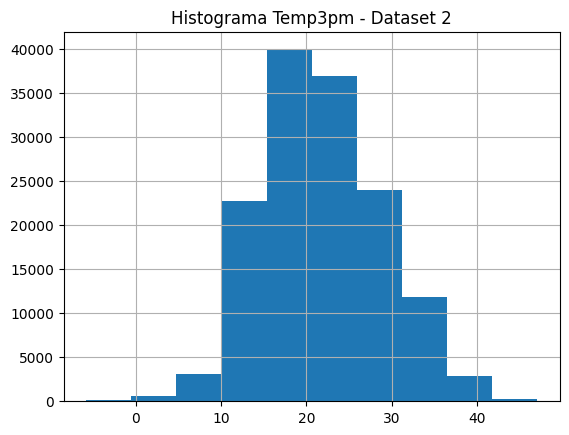

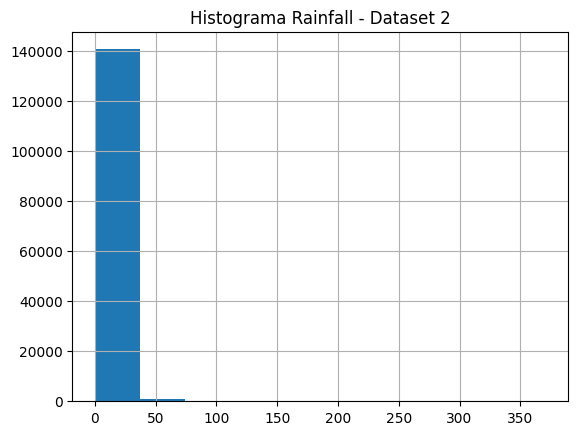

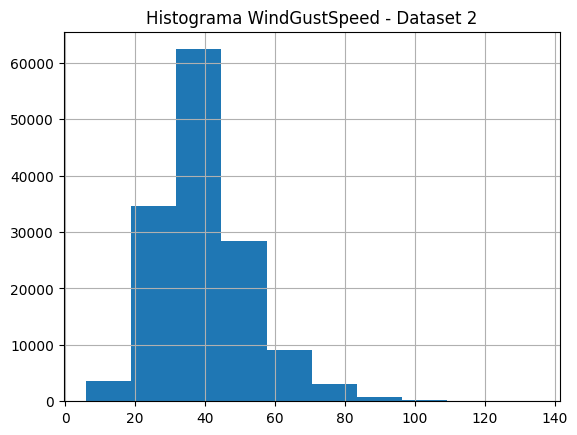

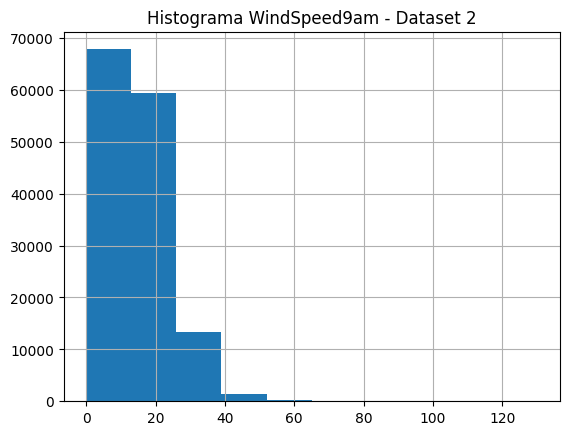

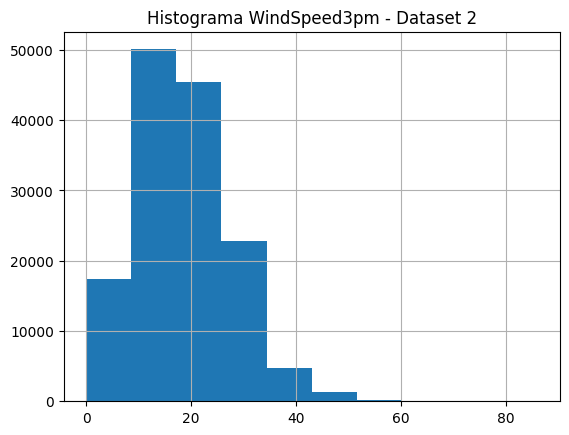

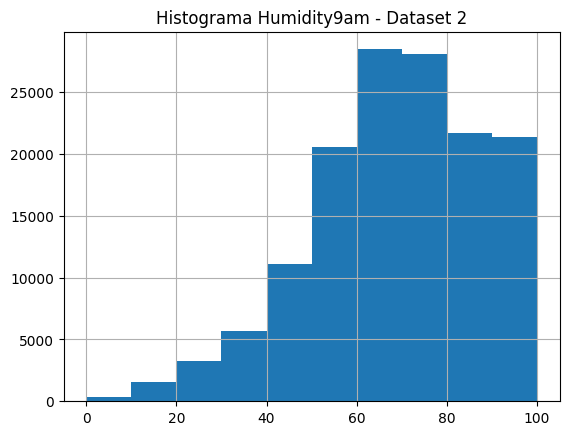

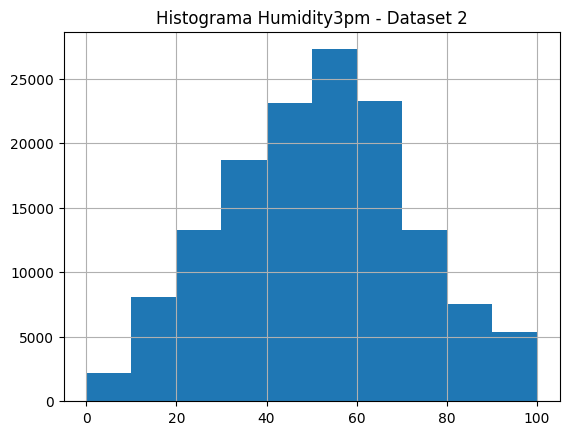

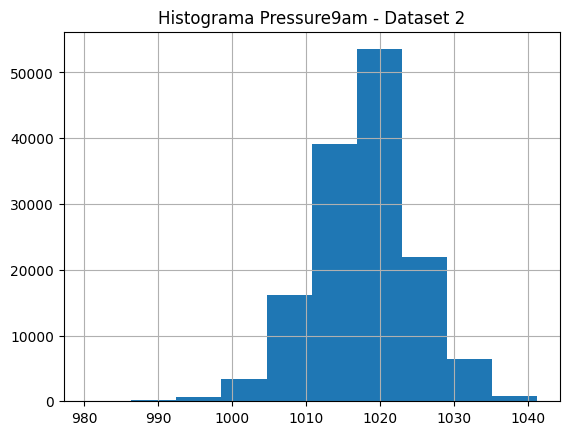

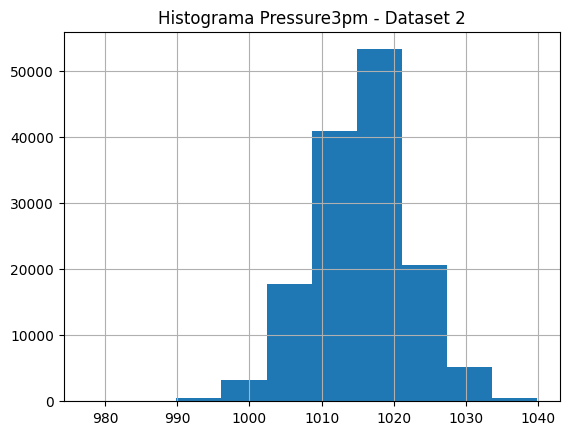

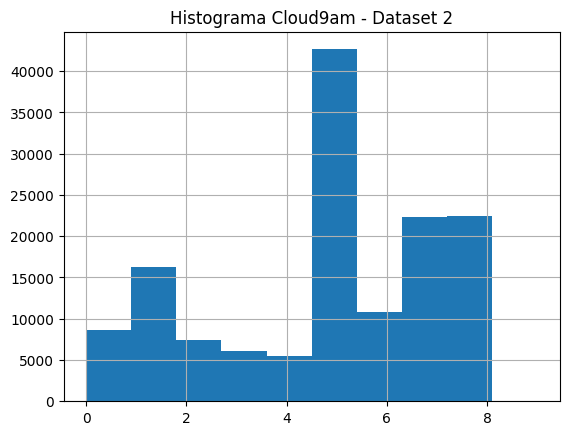

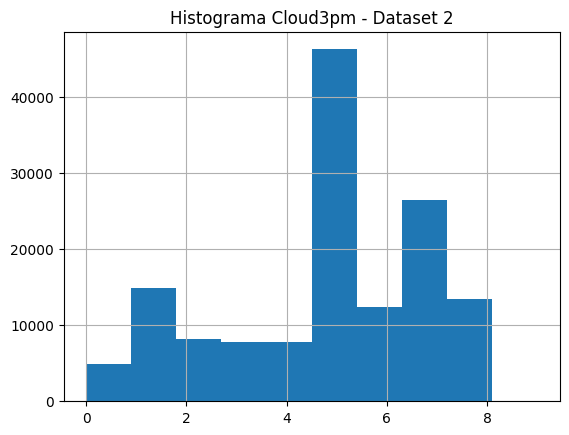

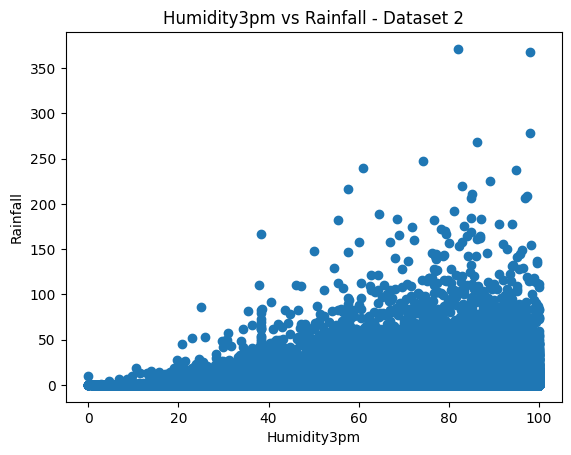

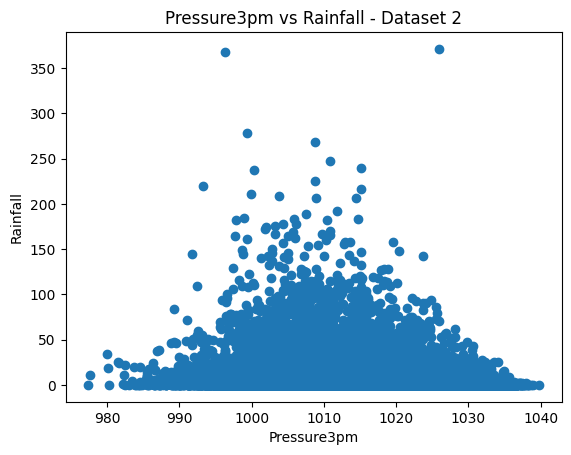

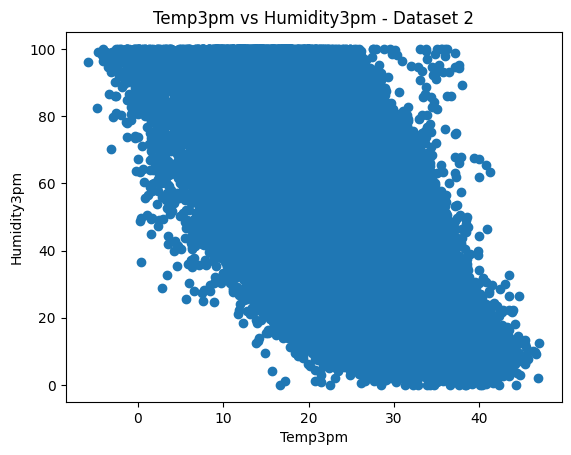

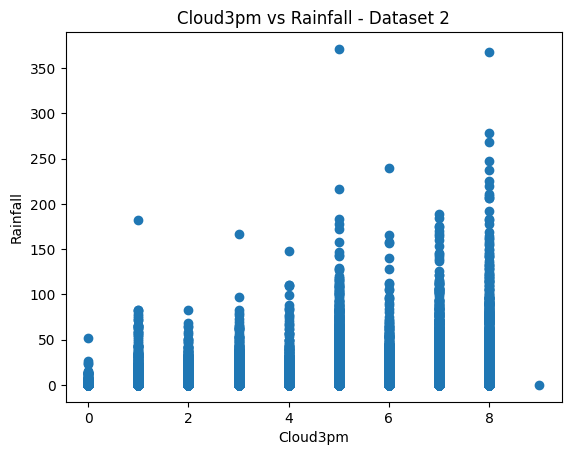

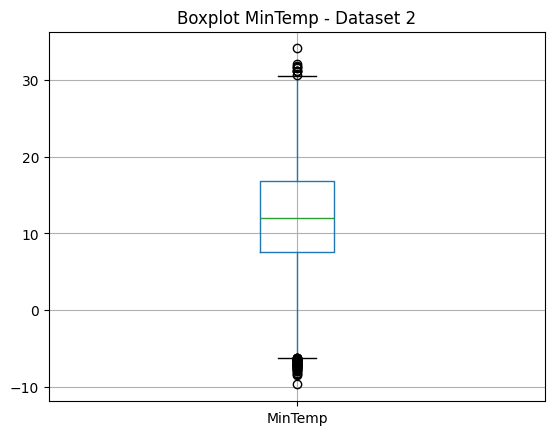

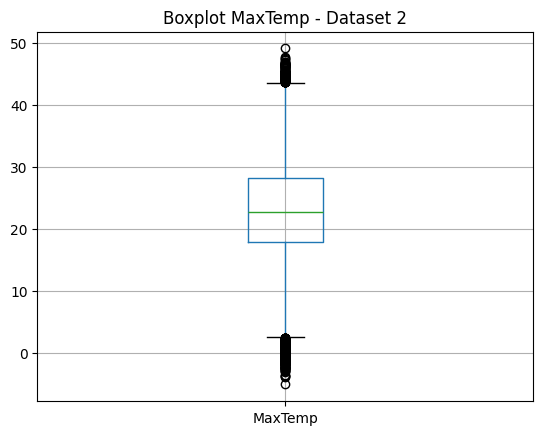

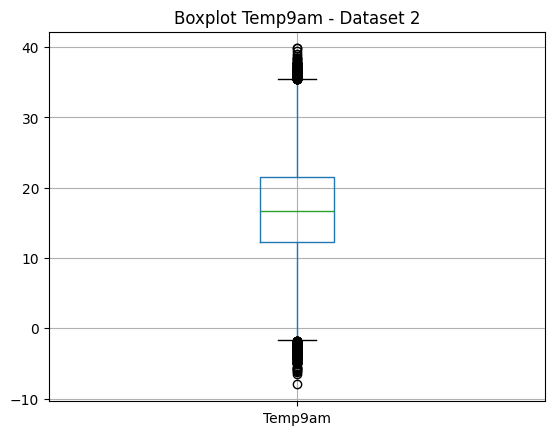

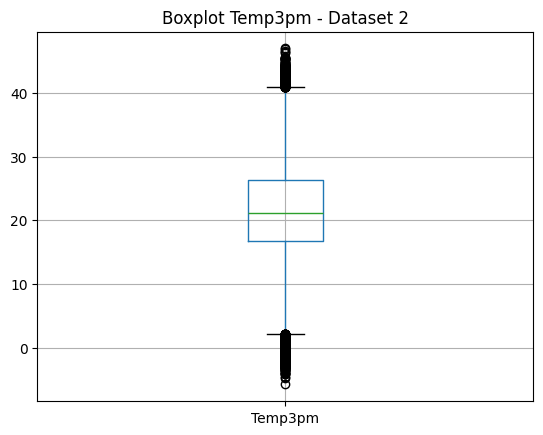

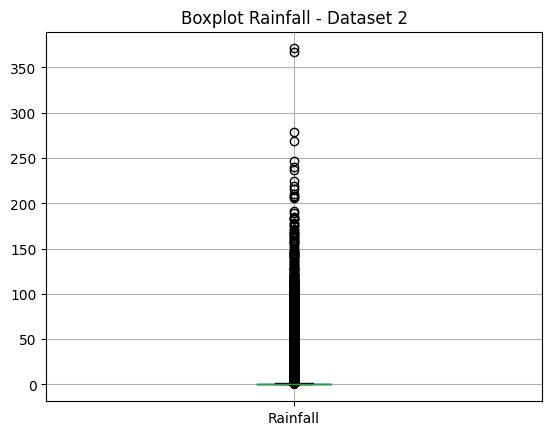

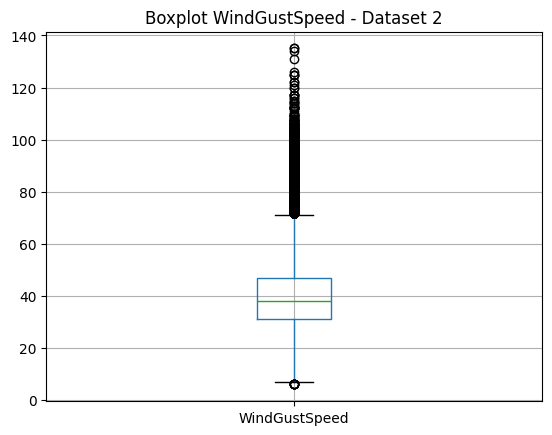

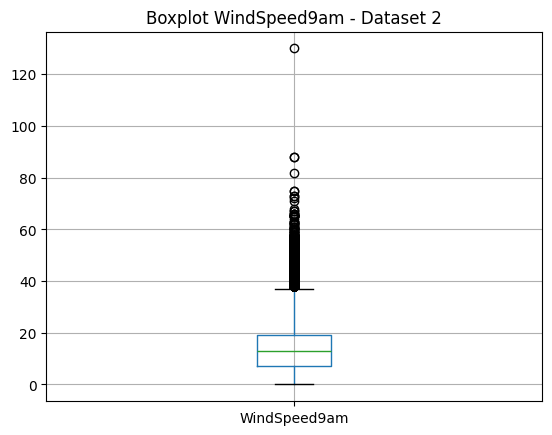

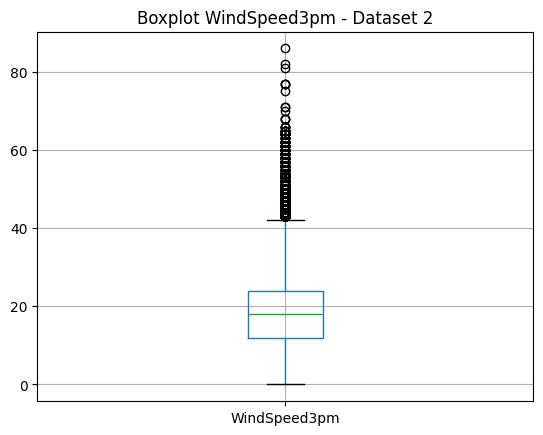

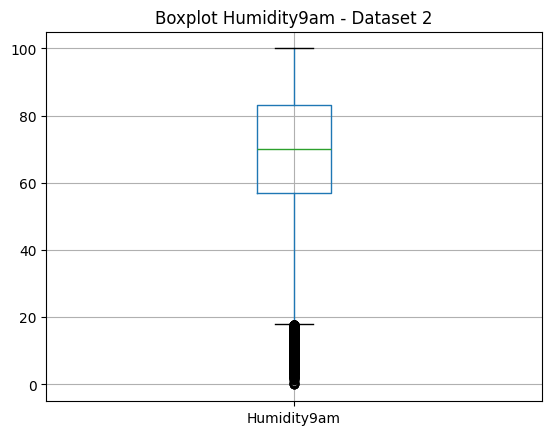

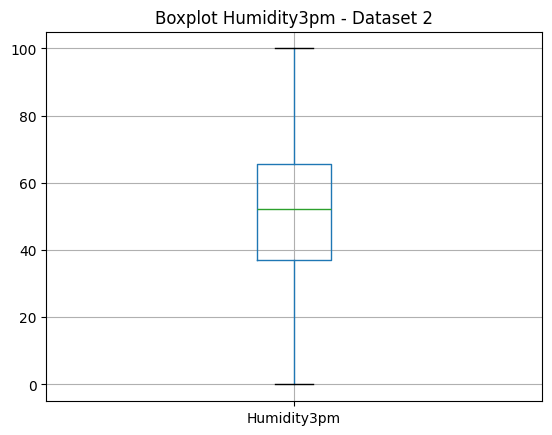

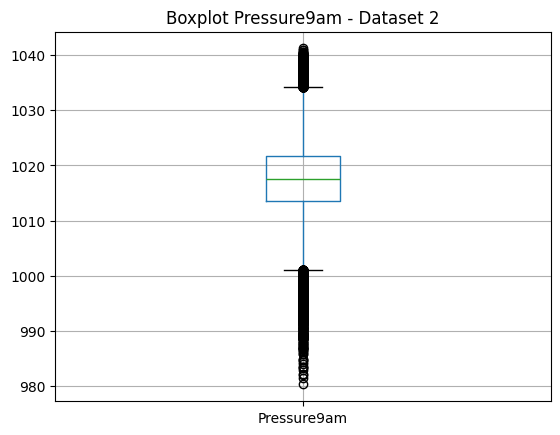

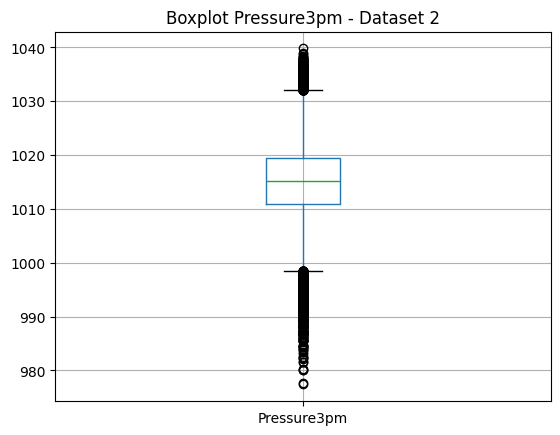

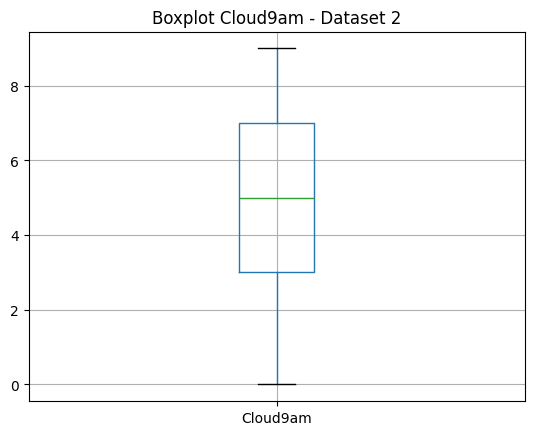

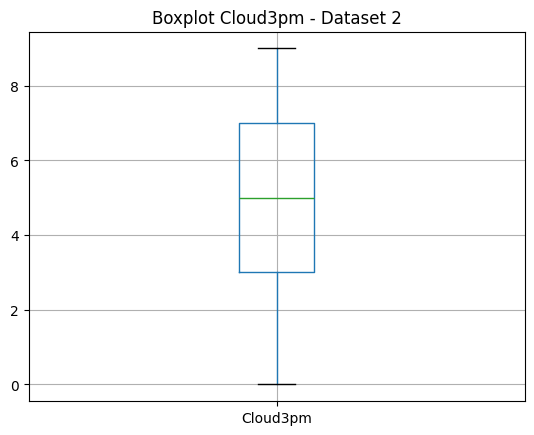

In [ ]:
df2 = pd.read_csv('dataset_sin_evap_sun.csv')

numericas = [
    'MinTemp','MaxTemp','Temp9am','Temp3pm',
    'Rainfall','WindGustSpeed','WindSpeed9am','WindSpeed3pm',
    'Humidity9am','Humidity3pm','Pressure9am','Pressure3pm',
    'Cloud9am','Cloud3pm'
]

numericas = [c for c in numericas if c in df2.columns]

for c in numericas:
    plt.figure()
    df2[c].hist()
    plt.title(f'Histograma {c} - Dataset 2')
    plt.show()

pares = [
    ('Humidity3pm','Rainfall'),
    ('Pressure3pm','Rainfall'),
    ('Temp3pm','Humidity3pm'),
    ('Cloud3pm','Rainfall')
]

for x,y in pares:
    if x in df2.columns and y in df2.columns:
        plt.figure()
        plt.scatter(df2[x], df2[y])
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f'{x} vs {y} - Dataset 2')
        plt.show()

for c in numericas:
    plt.figure()
    df2.boxplot(column=c)
    plt.title(f'Boxplot {c} - Dataset 2')
    plt.show()

In [ ]:
df1 = pd.read_csv('dataset_imputado.csv')

conteo = df1['RainTomorrow'].value_counts()
porcentaje = df1['RainTomorrow'].value_counts(normalize=True) * 100

print("Conteo:")
print(conteo)

print("\nPorcentaje:")
print(porcentaje)

Conteo:
RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

Porcentaje:
RainTomorrow
No     77.579087
Yes    22.420913
Name: proportion, dtype: float64


In [ ]:
df2 = pd.read_csv('dataset_sin_evap_sun.csv')

conteo = df2['RainTomorrow'].value_counts()
porcentaje = df2['RainTomorrow'].value_counts(normalize=True) * 100

print("Conteo:")
print(conteo)

print("\nPorcentaje:")
print(porcentaje)

Conteo:
RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

Porcentaje:
RainTomorrow
No     77.579087
Yes    22.420913
Name: proportion, dtype: float64


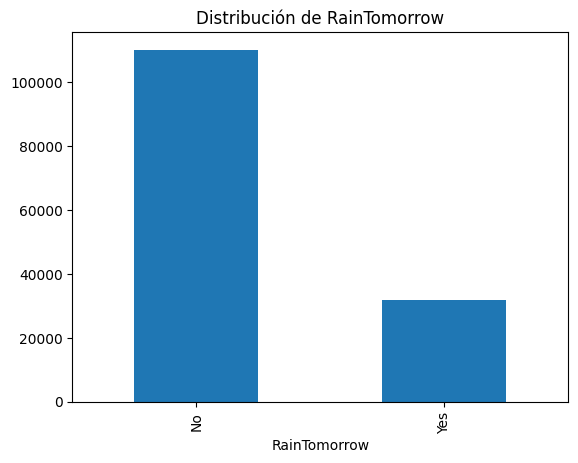

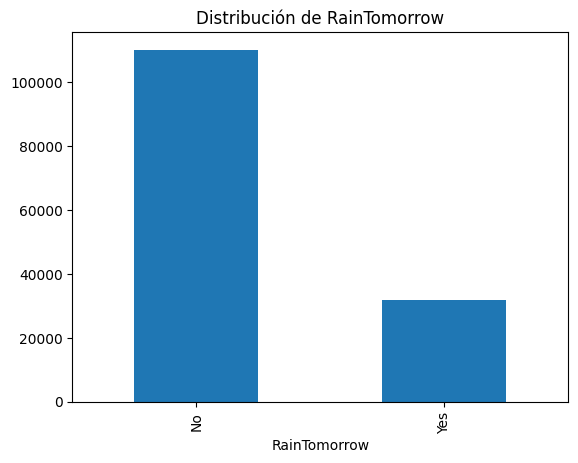

In [ ]:
df1['RainTomorrow'].value_counts().plot(kind='bar')
plt.title('Distribución de RainTomorrow')
plt.show()

df2['RainTomorrow'].value_counts().plot(kind='bar')
plt.title('Distribución de RainTomorrow')
plt.show()

El Dataset está claramente desbalanceado, por lo que se deberá solucionar este problema más adelante

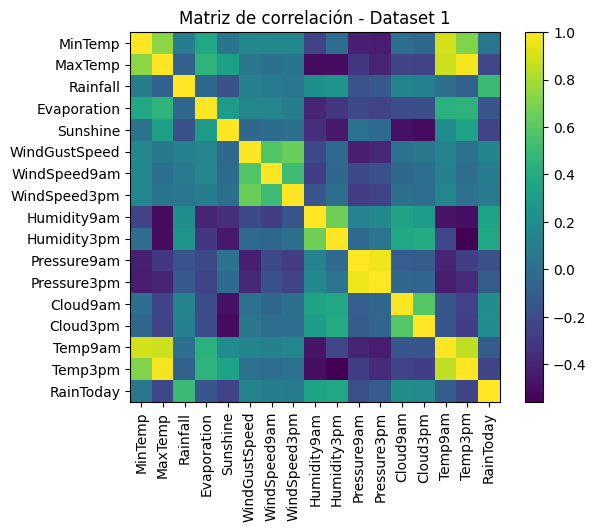

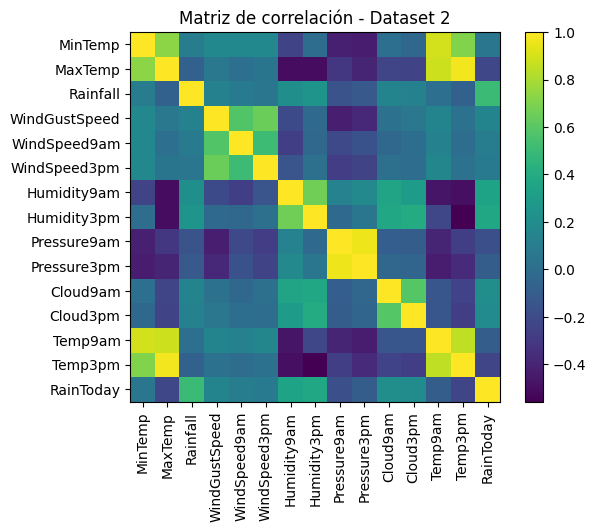

In [ ]:
df1 = pd.read_csv('dataset_imputado.csv')

df1 = df1[[c for c in df1.columns
           if not c.endswith('_missing')
           and not c.startswith('WindGustDir_')
           and not c.startswith('WindDir9am_')
           and not c.startswith('WindDir3pm_')]]

corr1 = df1.corr(numeric_only=True)

plt.figure()
plt.imshow(corr1)
plt.colorbar()
plt.title('Matriz de correlación - Dataset 1')
plt.xticks(range(len(corr1.columns)), corr1.columns, rotation=90)
plt.yticks(range(len(corr1.columns)), corr1.columns)
plt.show()

df2 = pd.read_csv('dataset_sin_evap_sun.csv')

df2 = df2[[c for c in df2.columns
           if not c.endswith('_missing')
           and not c.startswith('WindGustDir_')
           and not c.startswith('WindDir9am_')
           and not c.startswith('WindDir3pm_')]]

corr2 = df2.corr(numeric_only=True)

plt.figure()
plt.imshow(corr2)
plt.colorbar()
plt.title('Matriz de correlación - Dataset 2')
plt.xticks(range(len(corr2.columns)), corr2.columns, rotation=90)
plt.yticks(range(len(corr2.columns)), corr2.columns)
plt.show()

Division Train/Test

In [ ]:
df1 = pd.read_csv('dataset_imputado.csv')

X1 = df1.drop(columns=['RainTomorrow'])
y1 = df1['RainTomorrow']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

print(X1_train.shape, X1_test.shape)

(113722, 77) (28431, 77)


In [ ]:
df2 = pd.read_csv('dataset_sin_evap_sun.csv')

X2 = df2.drop(columns=['RainTomorrow'])
y2 = df2['RainTomorrow']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print(X2_train.shape, X2_test.shape)

(113722, 73) (28431, 73)


Escalado

In [ ]:
df = pd.read_csv('dataset_imputado.csv')

y = df['RainTomorrow']
X = df.drop(columns=['RainTomorrow'])

# Identificar columnas binarias (que ya están en formato 0 o 1)
cols_binarias = [c for c in X.columns if set(X[c].dropna().unique()).issubset({0,1})]

# Identificar columnas categóricas que necesitan codificación one-hot (además de las ya codificadas)
cols_categoricas_a_procesar = [c for c in X.columns if X[c].dtype == 'object' and c not in ['Date', 'Location']]

# Codificar las columnas categóricas
X = pd.get_dummies(X, columns=cols_categoricas_a_procesar, drop_first=True)

# Actualizar la lista de columnas numéricas
cols_numericas = [c for c in X.columns if X[c].dtype in ['int64', 'float64'] and c not in cols_binarias and c not in ['Date', 'Location']]

# Excluir 'Date' y 'Location' del escalado
X_to_scale = X[cols_numericas]
X_not_to_scale = X.drop(columns=cols_numericas + ['Date', 'Location'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_to_scale)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_to_scale.columns, index=X.index)

# Recombinar el DataFrame
X_final = pd.concat([X_scaled_df, X_not_to_scale], axis=1)

df_escalado = pd.concat([X_final, y], axis=1)

print(df_escalado.head())

    MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0  0.219513 -0.102201 -0.204950     -0.10318  0.160839       0.387273   
1 -0.762595  0.360678 -0.276146     -0.10318  0.160839       0.311457   
2  0.157157  0.416785 -0.276146     -0.10318  0.160839       0.463088   
3 -0.341691  0.781478 -0.276146     -0.10318  0.160839      -1.280669   
4  0.811896  1.286437 -0.157487     -0.10318  0.160839       0.084011   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  WindDir3pm_NW  \
0      0.562490      0.729481    -0.006051    -1.341863  ...          False   
1     -1.124943      0.502710    -1.514976    -1.424083  ...          False   
2      0.674986      0.956251    -1.720022    -0.969458  ...          False   
3     -0.449969     -0.971299    -1.215294    -1.598194  ...          False   
4     -0.899952     -0.177602     0.766814    -0.819528  ...           True   

   WindDir3pm_S  WindDir3pm_SE  WindDir3pm_SSE  WindDir3pm_SSW  WindDir3pm_SW  \
0    

In [ ]:
df = pd.read_csv('dataset_sin_evap_sun.csv')

y = df['RainTomorrow']
X = df.drop(columns=['RainTomorrow'])

# Identificar columnas binarias (que ya están en formato 0 o 1)
cols_binarias = [c for c in X.columns if set(X[c].dropna().unique()).issubset({0,1})]

# Identificar columnas categóricas que necesitan codificación one-hot (además de las ya codificadas)
cols_categoricas_a_procesar = [c for c in X.columns if X[c].dtype == 'object' and c not in ['Date', 'Location']]

# Codificar las columnas categóricas
X = pd.get_dummies(X, columns=cols_categoricas_a_procesar, drop_first=True)

# Actualizar la lista de columnas numéricas
cols_numericas = [c for c in X.columns if X[c].dtype in ['int64', 'float64'] and c not in cols_binarias and c not in ['Date', 'Location']]

# Excluir 'Date' y 'Location' del escalado
X_to_scale = X[cols_numericas]
X_not_to_scale = X.drop(columns=cols_numericas + ['Date', 'Location'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_to_scale)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_to_scale.columns, index=X.index)

# Recombinar el DataFrame
X_final = pd.concat([X_scaled_df, X_not_to_scale], axis=1)

df_escalado = pd.concat([X_final, y], axis=1)

print(df_escalado.head())

    MinTemp   MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  WindSpeed3pm  \
0  0.219513 -0.102201 -0.204950       0.387273      0.562490      0.729481   
1 -0.762595  0.360678 -0.276146       0.311457     -1.124943      0.502710   
2  0.157157  0.416785 -0.276146       0.463088      0.674986      0.956251   
3 -0.341691  0.781478 -0.276146      -1.280669     -0.449969     -0.971299   
4  0.811896  1.286437 -0.157487       0.084011     -0.899952     -0.177602   

   Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  ...  WindDir3pm_NW  \
0    -0.006051    -1.341863    -1.412798    -1.203450  ...          False   
1    -1.514976    -1.424083    -0.968644    -1.158604  ...          False   
2    -1.720022    -0.969458    -1.531239    -0.874584  ...          False   
3    -1.215294    -1.598194    -0.006309    -0.426130  ...          False   
4     0.766814    -0.819528    -0.998254    -1.397780  ...           True   

   WindDir3pm_S  WindDir3pm_SE  WindDir3pm_SSE  WindDir3pm_SSW  Wind